#  Global Economic Crisis Risk Prediction & Country Downfall Analysis (2000–2035)

**Capstone Project | SyntecxHub Internship – Task 4, Project 3**

**Author:** [Your Name]  
**Date:** April 2026  
**Tools:** Python, Pandas, Seaborn, Matplotlib, Scikit-learn  

---

## Project Overview

This project performs an end-to-end analysis of global economic conditions from 2000 to 2035 (including future projections). Using indicators such as inflation, external debt, forex reserves, GDP growth, currency devaluation, and conflict data, we:
- Identify historically collapsed economies
- Detect current high-risk nations  
- Predict future economic downfall countries
- Identify future strong economies
- Explain causes of economic decline
- Recommend recovery strategies

---
## Table of Contents
1. Setup & Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Key Visualizations
5. Machine Learning – High Risk Prediction
6. Actionable Insights & Recovery Recommendations

## 1. Setup & Data Loading

In [1]:
# Install required libraries (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Matplotlib style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [2]:
# ── Load all datasets ──────────────────────────────────────────────────────
# Upload these CSV files to your Colab session or Google Drive

raw_df    = pd.read_csv('global_economic_crisis_dataset.csv')
eda_df    = pd.read_csv('eda_ready_dataset.csv')
pred_df   = pd.read_csv('predictive_model_dataset.csv')
viz_df    = pd.read_csv('visualization_summary_dataset.csv')
dict_df   = pd.read_csv('data_dictionary.csv')

print(f"Raw Dataset:              {raw_df.shape}")
print(f"EDA Ready Dataset:        {eda_df.shape}")
print(f"Predictive Model Dataset: {pred_df.shape}")
print(f"Visualization Summary:    {viz_df.shape}")
print(f"Data Dictionary:          {dict_df.shape}")
print(f"\nCountries covered: {raw_df['Country'].nunique()}")
print(f"Years covered:     {raw_df['Year'].min()} – {raw_df['Year'].max()}")
print(f"Regions covered:   {raw_df['Region'].nunique()}")

Raw Dataset:              (1692, 37)
EDA Ready Dataset:        (1692, 37)
Predictive Model Dataset: (1692, 32)
Visualization Summary:    (1692, 17)
Data Dictionary:          (37, 6)

Countries covered: 47
Years covered:     2000 – 2035
Regions covered:   6


## 2. Data Cleaning

### Steps:
- Handle missing values
- Remove duplicates  
- Standardize string columns
- Correct data types
- Detect and cap outliers
- Create derived risk columns

In [3]:
# ── 2.1 Initial Data Quality Assessment ────────────────────────────────────
df = raw_df.copy()

print("=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0].to_frame('Count').assign(Pct=lambda x: (x['Count']/len(df)*100).round(2)))

print(f"\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print(f"\n=== DATA TYPES ===")
print(df.dtypes.value_counts())

=== MISSING VALUES ===
                            Count    Pct
GDP_Growth_Rate                50   2.96
Forex_Reserves_Billion_USD    827  48.88
Poverty_Rate                   98   5.79
Tourism_Revenue_Loss_Pct       66   3.90

=== DUPLICATES ===
Duplicate rows: 0

=== DATA TYPES ===
float64    23
int64      10
object      4
Name: count, dtype: int64


In [5]:
# ── 2.2 Handle Missing Values ──────────────────────────────────────────────

# GDP_Growth_Rate: fill with country-level median, then global median
df['GDP_Growth_Rate'] = df['GDP_Growth_Rate'].fillna(
    df.groupby('Country')['GDP_Growth_Rate'].transform('median')
).fillna(df['GDP_Growth_Rate'].median())

# Forex_Reserves: fill with country-level median, then global median
df['Forex_Reserves_Billion_USD'] = df['Forex_Reserves_Billion_USD'].fillna(
    df.groupby('Country')['Forex_Reserves_Billion_USD'].transform('median')
).fillna(df['Forex_Reserves_Billion_USD'].median())

# Poverty_Rate: fill with income-level group median
df['Poverty_Rate'] = df['Poverty_Rate'].fillna(
    df.groupby('Income_Level')['Poverty_Rate'].transform('median')
).fillna(df['Poverty_Rate'].median())

# Tourism_Revenue_Loss: fill with 0 (no loss recorded = no loss)
df['Tourism_Revenue_Loss_Pct'] = df['Tourism_Revenue_Loss_Pct'].fillna(0.0)

print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(" All missing values handled!")

Remaining missing values: 0
 All missing values handled!


In [6]:
# ── 2.3 Standardize & Correct Data Types ───────────────────────────────────

# Strip whitespace from string columns
for col in ['Country', 'Region', 'Income_Level', 'Inflation_Crisis_Level']:
    df[col] = df[col].str.strip()

# Ensure integer types
for col in ['Year', 'War_Conflict_Flag', 'Policy_Intervention_Flag', 'Is_Future_Prediction']:
    df[col] = df[col].astype(int)

print("Data types after cleaning:")
print(df.dtypes[['Country','Year','War_Conflict_Flag','GDP_Growth_Rate','Inflation_Rate']])
print("\n Data types corrected!")

Data types after cleaning:
Country               object
Year                   int64
War_Conflict_Flag      int64
GDP_Growth_Rate      float64
Inflation_Rate       float64
dtype: object

 Data types corrected!


In [7]:
# ── 2.4 Outlier Detection & Capping (IQR 1st–99th percentile) ─────────────
outlier_cols = ['Inflation_Rate', 'GDP_Growth_Rate', 'Currency_Devaluation_Percentage']

print("Outlier capping summary:")
for col in outlier_cols:
    q1, q3 = df[col].quantile(0.01), df[col].quantile(0.99)
    n_outliers = ((df[col] < q1) | (df[col] > q3)).sum()
    df[col] = df[col].clip(q1, q3)
    print(f"  {col}: {n_outliers} values capped → range [{q1:.2f}, {q3:.2f}]")

print("\n Outliers capped!")

Outlier capping summary:
  Inflation_Rate: 33 values capped → range [0.88, 503.45]
  GDP_Growth_Rate: 34 values capped → range [-9.67, 8.91]
  Currency_Devaluation_Percentage: 18 values capped → range [0.00, 221.35]

 Outliers capped!


In [8]:
# ── 2.5 Create Derived Risk Columns ───────────────────────────────────────

# Composite Risk Score (weighted)
df['Composite_Risk_Score'] = (
    df['Sovereign_Default_Risk_Score'] * 0.25 +
    df['Economic_Collapse_Probability'] * 0.25 +
    df['Political_Instability_Score'] * 3.0  +
    df['Inflation_Rate'].clip(0, 100) * 0.15 +
    df['External_Debt_to_GDP'] * 0.05
).round(2)

# High Risk Binary Flag
df['High_Risk_Flag'] = (
    (df['Economic_Collapse_Probability'] > 70) |
    (df['Sovereign_Default_Risk_Score'] > 50) |
    (df['Inflation_Rate'] > 20)
).astype(int)

# Debt-to-Forex Stress Ratio
df['Debt_to_Forex_Ratio'] = (
    df['External_Debt_to_GDP'] / (df['Forex_Reserves_Billion_USD'] + 0.01)
).round(2)

# Economic Classification
def classify_economy(row):
    if row['GDP_Growth_Rate'] >= 4 and row['Inflation_Rate'] <= 5 and row['Economic_Collapse_Probability'] <= 30:
        return 'Strong'
    elif row['Economic_Collapse_Probability'] >= 70 or row['Inflation_Rate'] >= 30:
        return 'In Crisis'
    elif row['GDP_Growth_Rate'] < 0:
        return 'Contracting'
    else:
        return 'Moderate'

df['Economic_Status'] = df.apply(classify_economy, axis=1)

print("Derived columns created:")
print(f"  Composite_Risk_Score | High_Risk_Flag | Debt_to_Forex_Ratio | Economic_Status")
print("\nEconomic Status Distribution:")
print(df['Economic_Status'].value_counts())
print("\n Feature engineering complete!")

Derived columns created:
  Composite_Risk_Score | High_Risk_Flag | Debt_to_Forex_Ratio | Economic_Status

Economic Status Distribution:
Economic_Status
In Crisis      911
Moderate       560
Strong         137
Contracting     84
Name: count, dtype: int64

 Feature engineering complete!


In [9]:
# ── 2.6 Save Cleaned Dataset ───────────────────────────────────────────────
df.to_csv('cleaned_global_economic_crisis_dataset.csv', index=False)
print(f" Saved: cleaned_global_economic_crisis_dataset.csv")
print(f"   Final shape: {df.shape} | Columns: {df.shape[1]}")

 Saved: cleaned_global_economic_crisis_dataset.csv
   Final shape: (1692, 41) | Columns: 41


## 3. Exploratory Data Analysis (EDA)

### EDA Questions:
1. Overall country economic overview
2. High economy → downfall countries
3. Currently risky countries
4. Future downfall predictions (2026–2035)
5. Future strong economies
6. Recovery strategies
7. Economic classification of all countries
8. Main reasons for economic collapse

In [10]:
# ── Separate historical vs future data ────────────────────────────────────
hist = df[df['Is_Future_Prediction'] == 0].copy()
future = df[df['Is_Future_Prediction'] == 1].copy()

print(f"Historical data (2000–2025): {len(hist):,} rows across {hist['Country'].nunique()} countries")
print(f"Future projections (2026–2035): {len(future):,} rows")
print(f"\nRegions: {df['Region'].unique().tolist()}")
print(f"Income Levels: {df['Income_Level'].unique().tolist()}")

Historical data (2000–2025): 1,222 rows across 47 countries
Future projections (2026–2035): 470 rows

Regions: ['South Asia', 'Americas', 'Europe', 'Asia-Pacific', 'Middle East', 'Africa']
Income Levels: ['Lower-Middle', 'Low', 'High', 'Upper-Middle']


In [11]:
# ── EDA Q1: Overall Country Economic Summary ──────────────────────────────
summary = hist.groupby('Country').agg(
    Region=('Region','first'),
    Income_Level=('Income_Level','first'),
    Avg_GDP_Growth=('GDP_Growth_Rate','mean'),
    Avg_Inflation=('Inflation_Rate','mean'),
    Avg_Collapse_Prob=('Economic_Collapse_Probability','mean'),
    Avg_Default_Risk=('Sovereign_Default_Risk_Score','mean'),
    Avg_Debt_pct=('External_Debt_to_GDP','mean'),
    Avg_Unemployment=('Unemployment_Rate','mean'),
    War_Conflict_Years=('War_Conflict_Flag','sum'),
    Economic_Status=('Economic_Status', lambda x: x.mode()[0])
).round(2)

print("=== Country Economic Overview (Historical Averages 2000–2025) ===\n")
print(summary[['Region','Avg_GDP_Growth','Avg_Inflation','Avg_Collapse_Prob','Economic_Status']].to_string())

=== Country Economic Overview (Historical Averages 2000–2025) ===

                    Region  Avg_GDP_Growth  Avg_Inflation  Avg_Collapse_Prob Economic_Status
Country                                                                                     
Afghanistan     South Asia           -5.66          17.20              78.42       In Crisis
Argentina         Americas            1.91          48.43              86.02       In Crisis
Australia     Asia-Pacific            1.11           2.92              33.20        Moderate
Bangladesh      South Asia            5.64           6.72              24.05        Moderate
Brazil            Americas            2.03           7.60              82.92       In Crisis
Canada            Americas            1.27           3.16              19.44        Moderate
China         Asia-Pacific            6.87           3.08              72.62       In Crisis
Egypt               Africa            3.88          10.58              65.89        Moderate
Eth

In [12]:
# ── EDA Q2: High Economy → Downfall Countries ──────────────────────────────

# Countries with peak GDP > 5% but later saw collapse prob > 80%
peak_gdp = hist.groupby('Country')['GDP_Growth_Rate'].max()
high_collapse = hist.groupby('Country')['Economic_Collapse_Probability'].mean()

downfall = pd.DataFrame({'Peak_GDP': peak_gdp, 'Avg_Collapse_Prob': high_collapse})
downfall = downfall[(downfall['Peak_GDP'] > 4) & (downfall['Avg_Collapse_Prob'] > 70)]
downfall = downfall.sort_values('Avg_Collapse_Prob', ascending=False)

print("Countries that went from high growth to economic crisis:")
print(downfall.head(10).round(2))

Countries that went from high growth to economic crisis:
             Peak_GDP  Avg_Collapse_Prob
Country                                 
Sri Lanka        8.89              96.96
Hungary          6.94              96.88
Ethiopia         8.91              96.53
UAE              6.04              95.51
Russia           6.98              95.23
Mexico           6.28              92.36
Greece           4.41              90.42
New Zealand      5.36              89.92
Morocco          6.89              86.30
Argentina        8.17              86.02


In [13]:
# ── EDA Q3: Currently Risky Countries ─────────────────────────────────────
recent = hist[hist['Year'] >= 2020]
current_risk = recent.groupby('Country').agg(
    Avg_Collapse_Prob=('Economic_Collapse_Probability','mean'),
    Avg_Inflation=('Inflation_Rate','mean'),
    Avg_Default_Risk=('Sovereign_Default_Risk_Score','mean'),
    High_Risk_Pct=('High_Risk_Flag','mean')
).round(2)
current_risk = current_risk.sort_values('Avg_Collapse_Prob', ascending=False)

print("=== Top 10 Currently High-Risk Countries (2020–2025) ===")
print(current_risk.head(10).to_string())

=== Top 10 Currently High-Risk Countries (2020–2025) ===
             Avg_Collapse_Prob  Avg_Inflation  Avg_Default_Risk  High_Risk_Pct
Country                                                                       
Afghanistan               99.0          21.72             24.10            1.0
Argentina                 99.0          83.38             32.55            1.0
Brazil                    99.0           8.92             15.72            1.0
China                     99.0           4.30              9.32            1.0
Indonesia                 99.0           6.35             10.53            1.0
Ethiopia                  99.0          16.49             14.08            1.0
Egypt                     99.0          10.85             17.87            1.0
Hungary                   99.0           7.97             17.97            1.0
Morocco                   99.0           6.22             11.70            1.0
New Zealand               99.0           4.27             12.88           

In [14]:
# ── EDA Q4: Future Downfall Predictions (2026–2035) ────────────────────────
future_risk = future.groupby('Country').agg(
    Avg_Collapse_Prob=('Economic_Collapse_Probability','mean'),
    Avg_Inflation=('Inflation_Rate','mean'),
    Avg_Default_Risk=('Sovereign_Default_Risk_Score','mean'),
    Avg_GDP=('GDP_Growth_Rate','mean')
).round(2)
future_risk = future_risk.sort_values('Avg_Collapse_Prob', ascending=False)

print("=== Top 10 Countries at Risk of Downfall (2026–2035) ===")
print(future_risk.head(10).to_string())

=== Top 10 Countries at Risk of Downfall (2026–2035) ===
             Avg_Collapse_Prob  Avg_Inflation  Avg_Default_Risk  Avg_GDP
Country                                                                 
Afghanistan               99.0          15.69             20.84    -5.40
Argentina                 99.0          27.38             23.60     1.66
Australia                 99.0           3.30             10.36     2.09
Brazil                    99.0           7.73             18.83     1.86
China                     99.0           2.70              9.70     7.00
Ethiopia                  99.0          19.57             14.32     6.55
Egypt                     99.0          10.62             15.69     3.66
Indonesia                 99.0           4.59             14.54     4.72
Hungary                   99.0           7.82             16.06     2.64
France                    99.0           2.40             18.33     0.09


In [15]:
# ── EDA Q5: Future Strong Economies ───────────────────────────────────────
future_strong = future.groupby('Country').agg(
    Avg_GDP=('GDP_Growth_Rate','mean'),
    Avg_Inflation=('Inflation_Rate','mean'),
    Avg_Collapse_Prob=('Economic_Collapse_Probability','mean'),
    Avg_Recovery=('Recovery_Potential_Score','mean')
).round(2)
future_strong = future_strong[future_strong['Avg_Collapse_Prob'] < 50].sort_values('Avg_GDP', ascending=False)

print("=== Top 10 Projected Strong Economies (2026–2035) ===")
print(future_strong.head(10).to_string())

=== Top 10 Projected Strong Economies (2026–2035) ===
              Avg_GDP  Avg_Inflation  Avg_Collapse_Prob  Avg_Recovery
Country                                                              
India            7.12           7.10               4.12         57.78
Bangladesh       7.01           6.34              25.97         62.63
Philippines      5.94           4.36              25.41         55.96
Qatar            4.57           2.62              23.61         54.08
Poland           4.17           4.60              28.99         48.94
Israel           2.67           3.30              39.83         52.16
Saudi Arabia     2.66           2.81               3.46         53.49
Sweden           2.43           2.27              34.39         60.95
Nigeria          1.82          19.88              48.75         48.15
Canada           1.55           2.84              20.90         46.87


In [16]:
# ── EDA Q6: Recovery Strategies ───────────────────────────────────────────
# Countries with high recovery potential score (structural resilience)
recovery = hist.groupby('Country').agg(
    Avg_Recovery=('Recovery_Potential_Score','mean'),
    Avg_Collapse=('Economic_Collapse_Probability','mean'),
    Policy_Interventions=('Policy_Intervention_Flag','sum'),
    Avg_GDP=('GDP_Growth_Rate','mean')
).round(2)
recovery = recovery.sort_values('Avg_Recovery', ascending=False)

print("=== Top Countries by Recovery Potential ===")
print(recovery.head(10).to_string())

print("\n=== Recovery Strategy Insights ===")
high_rec = recovery[recovery['Avg_Recovery'] > 70]
print(f"Countries with recovery score > 70: {len(high_rec)}")
print(f"Their avg GDP growth: {high_rec['Avg_GDP'].mean():.2f}%")
print(f"Their avg collapse prob: {high_rec['Avg_Collapse'].mean():.1f}%")

=== Top Countries by Recovery Potential ===
             Avg_Recovery  Avg_Collapse  Policy_Interventions  Avg_GDP
Country                                                               
Ethiopia            93.77         96.53                     2     7.23
Russia              93.33         95.23                     2     2.73
Hungary             93.31         96.88                     5     2.92
Sri Lanka           93.29         96.96                     6     3.70
UAE                 93.18         95.51                     1     2.79
Mexico              91.67         92.36                     2     2.73
New Zealand         89.27         89.92                     3     2.16
Morocco             87.50         86.30                     6     3.32
Brazil              86.73         82.92                     3     2.03
Kenya               86.15         84.96                     1     4.96

=== Recovery Strategy Insights ===
Countries with recovery score > 70: 19
Their avg GDP growth: 2.80%
T

In [17]:
# ── EDA Q7: Economic Classification of All Countries ──────────────────────
classification = hist.groupby('Country')['Economic_Status'].apply(
    lambda x: x.value_counts().idxmax()
).reset_index()
classification.columns = ['Country','Dominant_Status']
print(classification['Dominant_Status'].value_counts())
print("\n", classification.to_string())

Dominant_Status
In Crisis    23
Moderate     21
Strong        3
Name: count, dtype: int64

          Country Dominant_Status
0    Afghanistan       In Crisis
1      Argentina       In Crisis
2      Australia        Moderate
3     Bangladesh        Moderate
4         Brazil       In Crisis
5         Canada        Moderate
6          China       In Crisis
7          Egypt        Moderate
8       Ethiopia       In Crisis
9         France        Moderate
10       Germany        Moderate
11        Greece       In Crisis
12       Hungary       In Crisis
13         India        Moderate
14     Indonesia       In Crisis
15          Iran        Moderate
16        Israel        Moderate
17         Italy        Moderate
18         Japan       In Crisis
19         Kenya       In Crisis
20       Lebanon       In Crisis
21      Malaysia          Strong
22        Mexico       In Crisis
23       Morocco       In Crisis
24       Myanmar       In Crisis
25         Nepal        Moderate
26   Netherlands 

In [18]:
# ── EDA Q8: Main Reasons for Economic Collapse ────────────────────────────

# Correlation with collapse probability
numeric_cols = ['Inflation_Rate','External_Debt_to_GDP','Unemployment_Rate',
                'Political_Instability_Score','War_Conflict_Flag',
                'Currency_Devaluation_Percentage','Money_Supply_Growth',
                'Sovereign_Default_Risk_Score','Oil_Dependency_Score',
                'Import_Dependency_Percentage']

corr_with_collapse = hist[numeric_cols + ['Economic_Collapse_Probability']].corr()[
    'Economic_Collapse_Probability'
].drop('Economic_Collapse_Probability').sort_values(ascending=False)

print("=== Correlation with Economic Collapse Probability ===")
print(corr_with_collapse.round(3))

=== Correlation with Economic Collapse Probability ===
Sovereign_Default_Risk_Score       0.326
External_Debt_to_GDP               0.308
Money_Supply_Growth                0.258
Currency_Devaluation_Percentage    0.236
Inflation_Rate                     0.220
Unemployment_Rate                  0.215
Political_Instability_Score        0.144
Import_Dependency_Percentage       0.144
War_Conflict_Flag                  0.079
Oil_Dependency_Score               0.064
Name: Economic_Collapse_Probability, dtype: float64


## 4. Key Visualizations

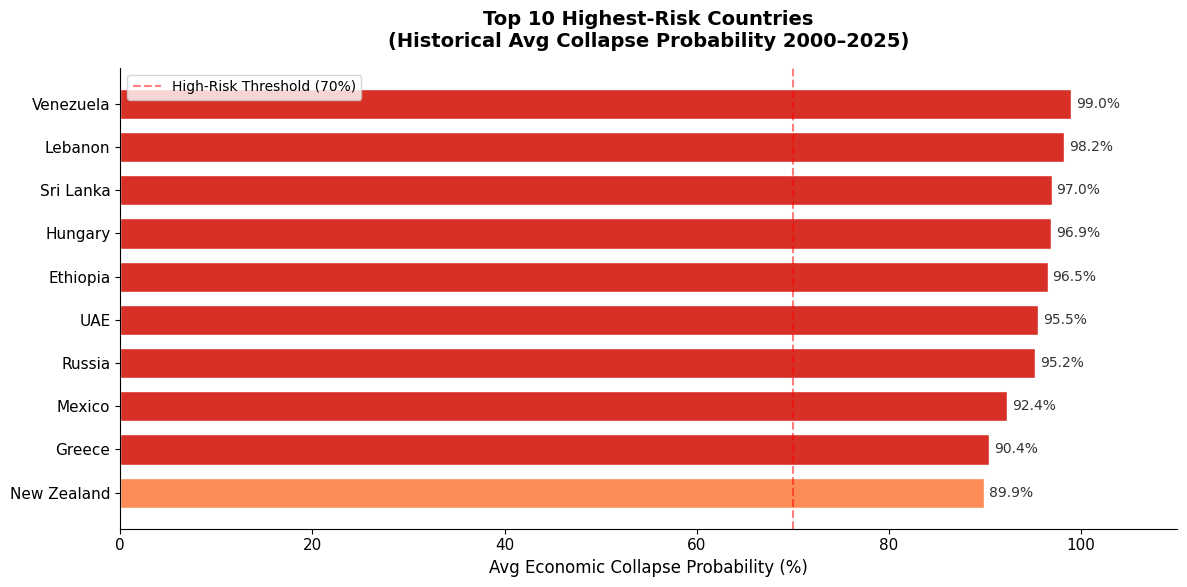

Visualization 1 saved


In [19]:
# ── VIZ 1: Top 10 High-Risk Countries by Collapse Probability ─────────────
fig, ax = plt.subplots(figsize=(12, 6))

top10 = hist.groupby('Country')['Economic_Collapse_Probability'].mean().sort_values(ascending=False).head(10)

colors = ['#d73027' if v > 90 else '#fc8d59' if v > 70 else '#fee090' for v in top10.values]
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='white', height=0.7)

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, color='#333')

ax.set_xlabel('Avg Economic Collapse Probability (%)', fontsize=12)
ax.set_title('Top 10 Highest-Risk Countries\n(Historical Avg Collapse Probability 2000–2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(70, color='red', linestyle='--', alpha=0.5, label='High-Risk Threshold (70%)')
ax.legend(fontsize=10)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig('viz1_top_risk_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 1 saved")

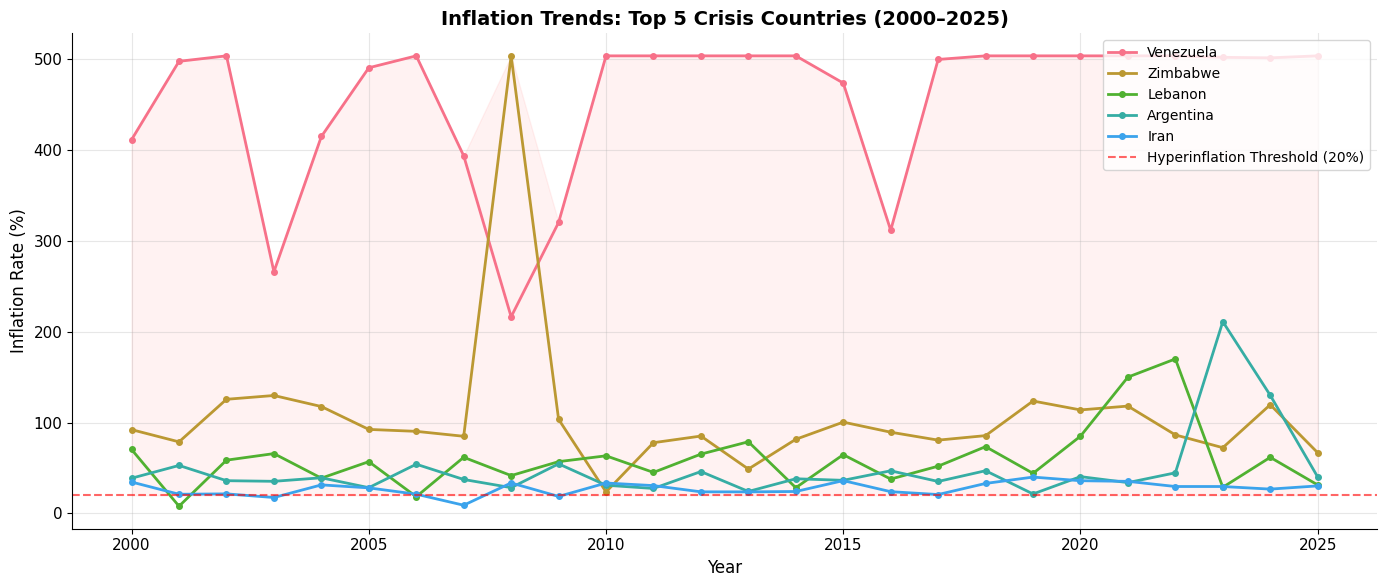

Visualization 2 saved


In [20]:
# ── VIZ 2: Inflation Trends – Top 5 High-Inflation Countries ─────────────
fig, ax = plt.subplots(figsize=(14, 6))

top_inflation = hist.groupby('Country')['Inflation_Rate'].mean().sort_values(ascending=False).head(5).index

for country in top_inflation:
    data = hist[hist['Country']==country].sort_values('Year')
    ax.plot(data['Year'], data['Inflation_Rate'], marker='o', markersize=4, label=country, linewidth=2)

ax.axhline(20, color='red', linestyle='--', alpha=0.6, label='Hyperinflation Threshold (20%)')
ax.fill_between(hist['Year'].unique(), 20,
                hist.groupby('Year')['Inflation_Rate'].max().reindex(hist['Year'].unique(), fill_value=20),
                alpha=0.05, color='red')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Inflation Rate (%)', fontsize=12)
ax.set_title('Inflation Trends: Top 5 Crisis Countries (2000–2025)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz2_inflation_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 2 saved")

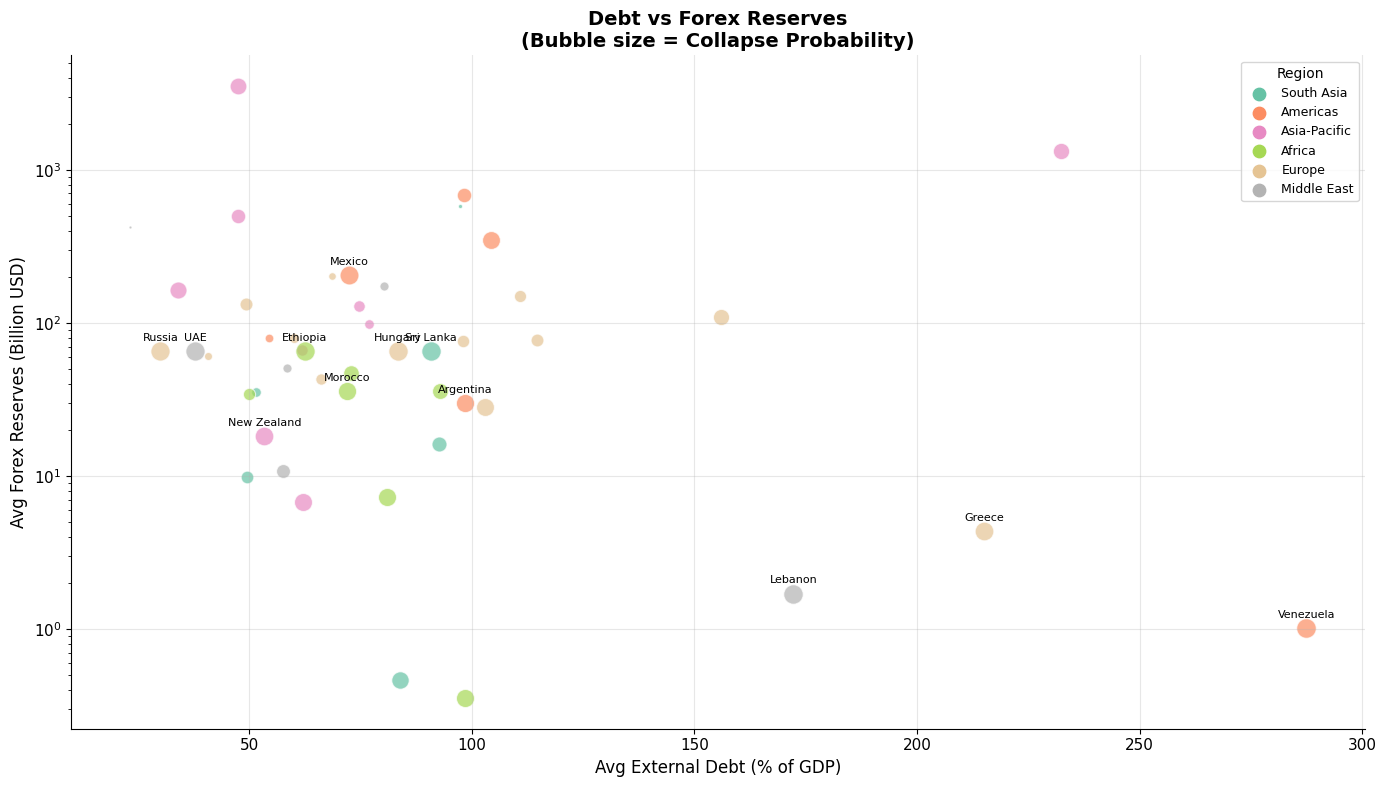

Visualization 3 saved


In [22]:
# ── VIZ 3: External Debt vs Forex Reserves (Bubble Chart) ───────────────
fig, ax = plt.subplots(figsize=(14, 8))

country_data = hist.groupby('Country').agg(
    Avg_Debt=('External_Debt_to_GDP','mean'),
    Avg_Forex=('Forex_Reserves_Billion_USD','mean'),
    Avg_Collapse=('Economic_Collapse_Probability','mean'),
    Region=('Region','first')
).reset_index()

regions = country_data['Region'].unique()
colors_r = plt.cm.Set2(np.linspace(0, 1, len(regions)))
region_color_map = dict(zip(regions, colors_r))

for _, row in country_data.iterrows():
    color = region_color_map[row['Region']]
    size = row['Avg_Collapse'] * 2
    ax.scatter(row['Avg_Debt'], row['Avg_Forex'], s=size, color=color, alpha=0.7, edgecolors='white', linewidths=0.8)
    if row['Avg_Collapse'] > 85:
        ax.annotate(row['Country'], (row['Avg_Debt'], row['Avg_Forex']),
                    fontsize=8, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')

for region, color in region_color_map.items():
    ax.scatter([], [], color=color, s=80, label=region)

ax.set_xlabel('Avg External Debt (% of GDP)', fontsize=12)
ax.set_ylabel('Avg Forex Reserves (Billion USD)', fontsize=12)
ax.set_title('Debt vs Forex Reserves\n(Bubble size = Collapse Probability)', fontsize=14, fontweight='bold')
ax.legend(title='Region', fontsize=9, title_fontsize=10)
ax.set_yscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('viz3_debt_forex.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 3 saved")

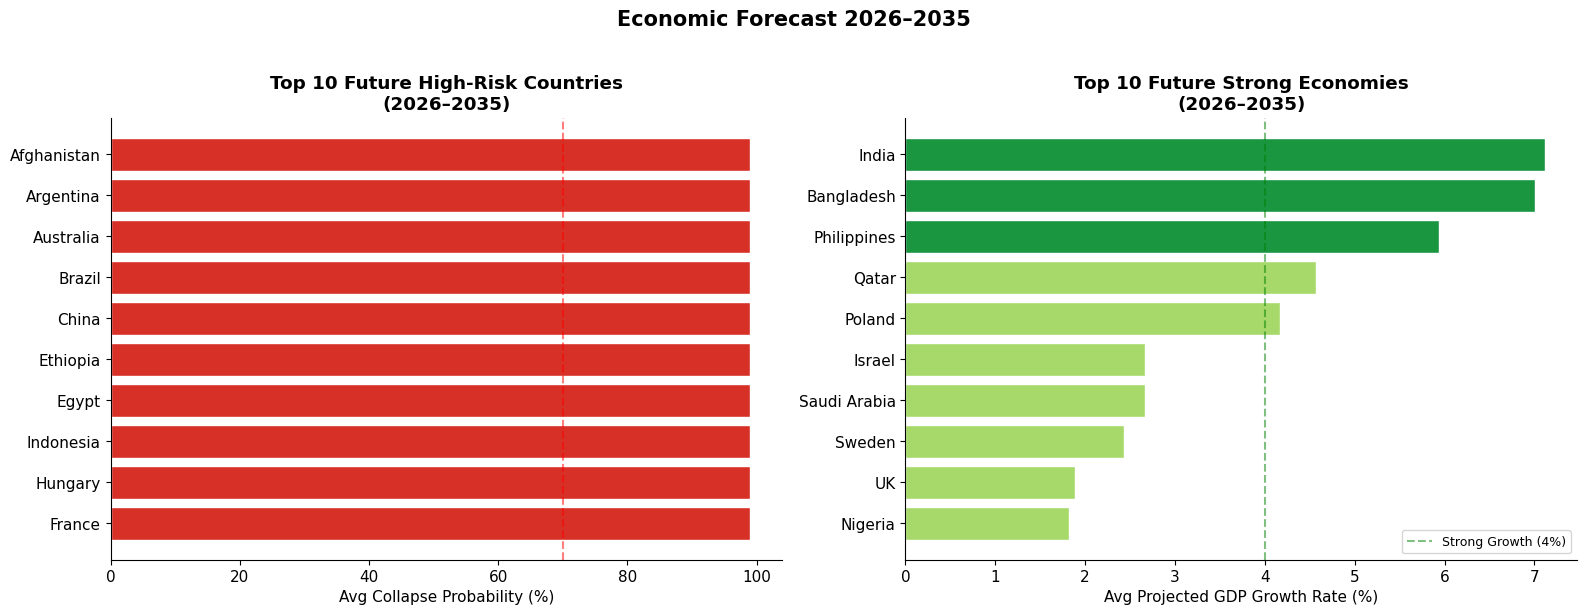

Visualization 4 saved


In [24]:
# ── VIZ 4: Future GDP Growth Projections (2026–2035) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Future High Risk
fut_risk = future.groupby('Country')['Economic_Collapse_Probability'].mean().sort_values(ascending=False).head(10)
colors_risk = ['#d73027' if v > 90 else '#fc8d59' for v in fut_risk.values]
axes[0].barh(fut_risk.index[::-1], fut_risk.values[::-1], color=colors_risk[::-1], edgecolor='white')
axes[0].set_xlabel('Avg Collapse Probability (%)')
axes[0].set_title('Top 10 Future High-Risk Countries\n(2026–2035)', fontweight='bold')
axes[0].axvline(70, color='red', linestyle='--', alpha=0.5)

# Future Strong
fut_strong = future.groupby('Country').agg(
    gdp=('GDP_Growth_Rate','mean'), collapse=('Economic_Collapse_Probability','mean')
)
fut_strong = fut_strong[fut_strong['collapse'] < 60].sort_values('gdp', ascending=False).head(10)
colors_strong = ['#1a9641' if v > 5 else '#a6d96a' for v in fut_strong['gdp'].values]
axes[1].barh(fut_strong.index[::-1], fut_strong['gdp'].values[::-1], color=colors_strong[::-1], edgecolor='white')
axes[1].set_xlabel('Avg Projected GDP Growth Rate (%)')
axes[1].set_title('Top 10 Future Strong Economies\n(2026–2035)', fontweight='bold')
axes[1].axvline(4, color='green', linestyle='--', alpha=0.5, label='Strong Growth (4%)')
axes[1].legend(fontsize=9)

plt.suptitle('Economic Forecast 2026–2035', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz4_future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization 4 saved")

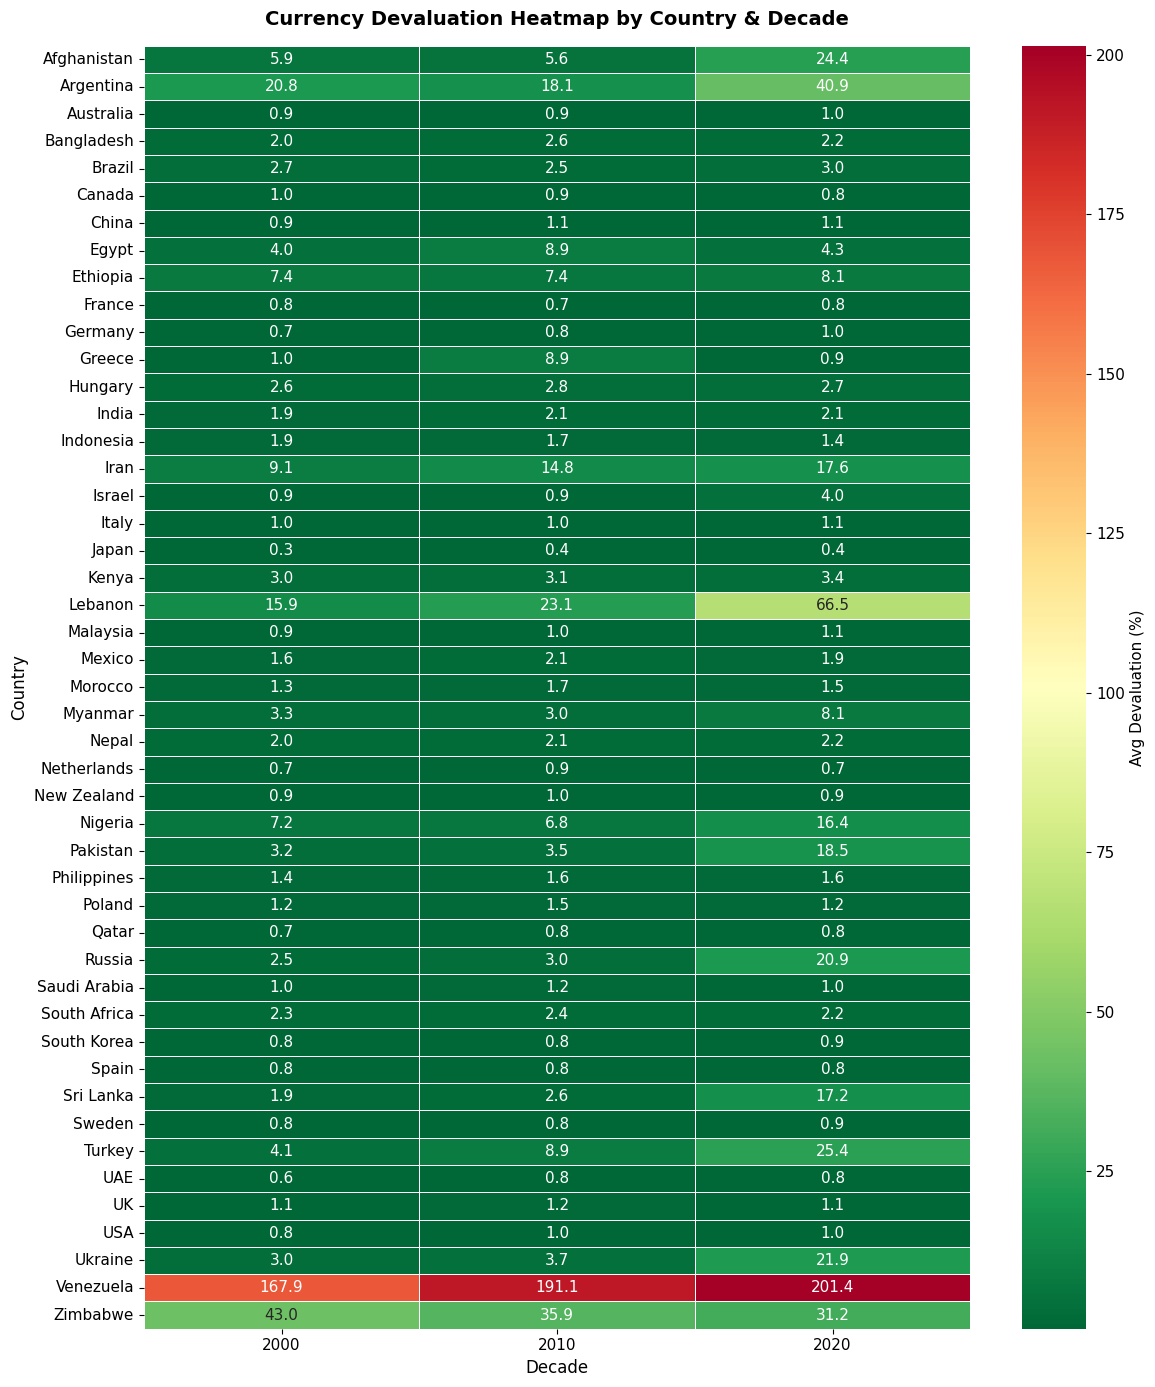

 Visualization 5 saved


In [25]:
# ── VIZ 5: Currency Devaluation Heatmap by Country & Decade ─────────────
hist['Decade'] = (hist['Year'] // 10) * 10
pivot = hist.pivot_table(values='Currency_Devaluation_Percentage',
                         index='Country', columns='Decade', aggfunc='mean').fillna(0)

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Avg Devaluation (%)'}, ax=ax)
ax.set_title('Currency Devaluation Heatmap by Country & Decade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('viz5_devaluation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualization 5 saved")

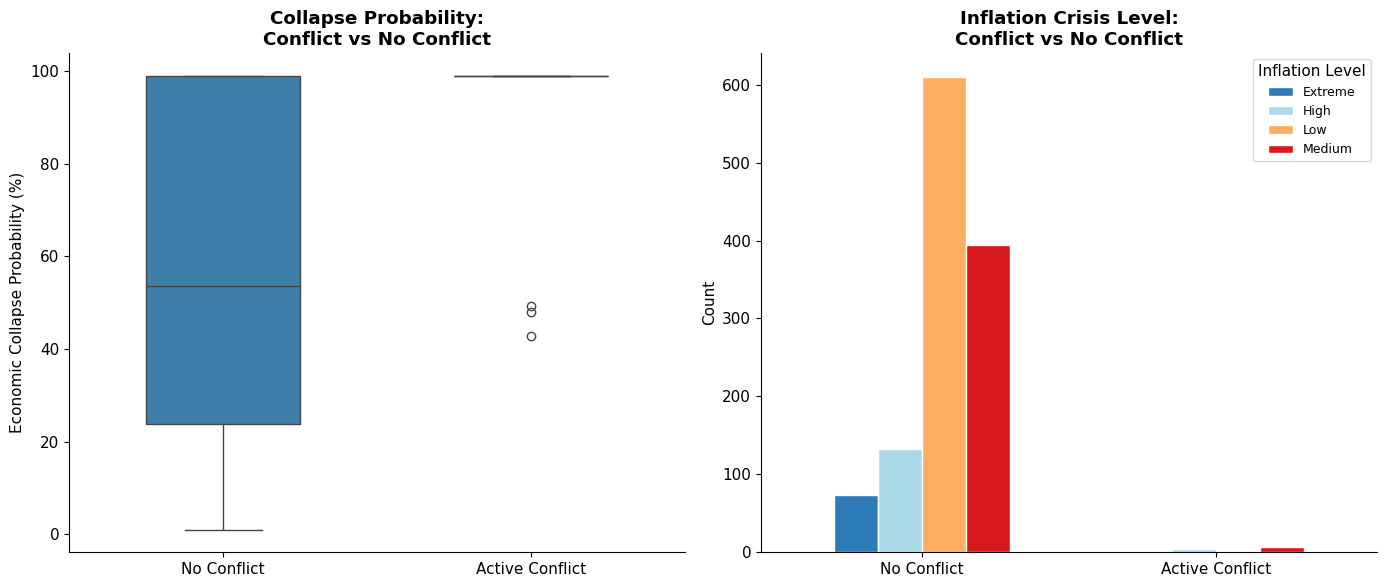

 Visualization 6 saved


In [26]:
# ── VIZ 6: Conflict Impact on Economic Collapse ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
conflict_data = hist[['War_Conflict_Flag', 'Economic_Collapse_Probability']].copy()
conflict_data['War_Conflict'] = conflict_data['War_Conflict_Flag'].map({0: 'No Conflict', 1: 'Active Conflict'})
sns.boxplot(data=conflict_data, x='War_Conflict', y='Economic_Collapse_Probability',
            palette=['#2b83ba', '#d7191c'], ax=axes[0], width=0.5)
axes[0].set_title('Collapse Probability:\nConflict vs No Conflict', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Economic Collapse Probability (%)')

# Avg inflation by conflict
inf_by_conflict = hist.groupby(['War_Conflict_Flag', 'Inflation_Crisis_Level']).size().unstack(fill_value=0)
inf_by_conflict.index = ['No Conflict', 'Active Conflict']
inf_by_conflict.plot(kind='bar', ax=axes[1], color=['#2c7bb6','#abd9e9','#fdae61','#d7191c'],
                     edgecolor='white', width=0.6)
axes[1].set_title('Inflation Crisis Level:\nConflict vs No Conflict', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Inflation Level', fontsize=9)

plt.tight_layout()
plt.savefig('viz6_conflict_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualization 6 saved")

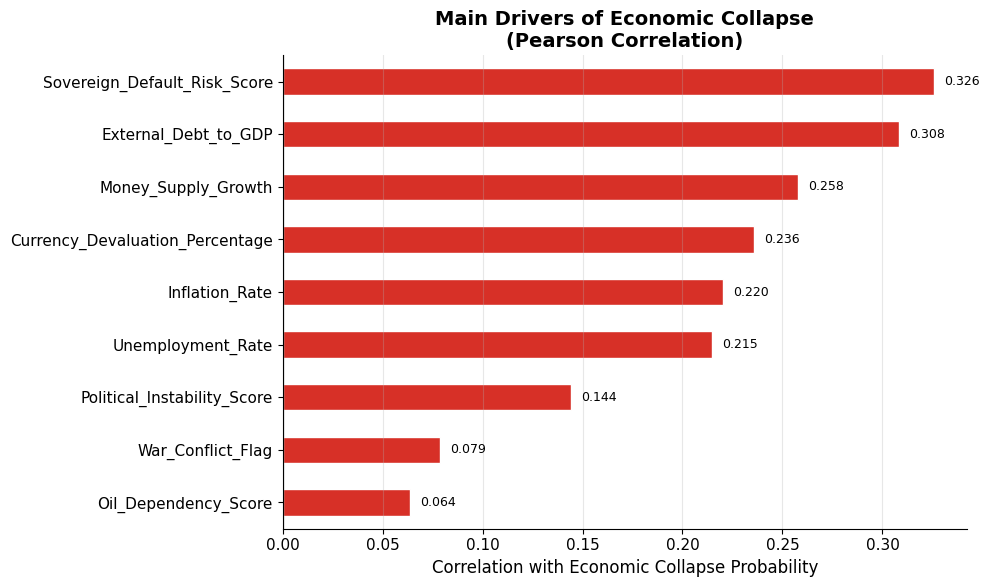

 Visualization 7 saved


In [27]:
# ── VIZ 7: Reasons for Economic Collapse (Feature Correlation) ──────────
fig, ax = plt.subplots(figsize=(10, 6))

numeric_cols = ['Inflation_Rate','External_Debt_to_GDP','Unemployment_Rate',
                'Political_Instability_Score','War_Conflict_Flag',
                'Currency_Devaluation_Percentage','Money_Supply_Growth',
                'Sovereign_Default_Risk_Score','Oil_Dependency_Score']

corr = hist[numeric_cols + ['Economic_Collapse_Probability']].corr()['Economic_Collapse_Probability'].drop('Economic_Collapse_Probability').sort_values()

colors_c = ['#d73027' if v > 0 else '#1a9641' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors_c, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Economic Collapse Probability', fontsize=12)
ax.set_title('Main Drivers of Economic Collapse\n(Pearson Correlation)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(corr.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('viz7_collapse_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualization 7 saved")

## 5. Machine Learning – High-Risk Country Prediction

### Models:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

**Target Variable:** `High_Risk_Flag` (1 = High Risk, 0 = Not High Risk)

In [28]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)

# ── Prepare features ─────────────────────────────────────────────────────
feature_cols = [
    'GDP_Growth_Rate','Inflation_Rate','Food_Inflation_Rate',
    'External_Debt_to_GDP','Forex_Reserves_Billion_USD',
    'Unemployment_Rate','Political_Instability_Score',
    'War_Conflict_Flag','Currency_Devaluation_Percentage',
    'Sovereign_Default_Risk_Score','Supply_Chain_Disruption_Score',
    'Oil_Dependency_Score','Import_Dependency_Percentage',
    'Money_Supply_Growth','Consumer_Purchasing_Power'
]

target_col = 'High_Risk_Flag'

# Use historical data only
ml_data = df[df['Is_Future_Prediction'] == 0][feature_cols + [target_col]].dropna()

X = ml_data[feature_cols]
y = ml_data[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"\nClass distribution:\n{y.value_counts(normalize=True).round(3)}")

Training samples: 977
Testing samples:  245

Class distribution:
High_Risk_Flag
0    0.516
1    0.484
Name: proportion, dtype: float64


In [29]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== LOGISTIC REGRESSION ===
Accuracy: 0.7469
ROC-AUC:  0.8335

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.84      0.77       126
           1       0.79      0.65      0.71       119

    accuracy                           0.75       245
   macro avg       0.76      0.74      0.74       245
weighted avg       0.75      0.75      0.74       245



In [30]:
# ── Model 2: Decision Tree ────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== DECISION TREE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

=== DECISION TREE ===
Accuracy: 0.8735
ROC-AUC:  0.9282

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89       126
           1       0.94      0.79      0.86       119

    accuracy                           0.87       245
   macro avg       0.88      0.87      0.87       245
weighted avg       0.88      0.87      0.87       245



In [31]:
# ── Model 3: Random Forest ────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.9061
ROC-AUC:  0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       126
           1       0.90      0.91      0.90       119

    accuracy                           0.91       245
   macro avg       0.91      0.91      0.91       245
weighted avg       0.91      0.91      0.91       245



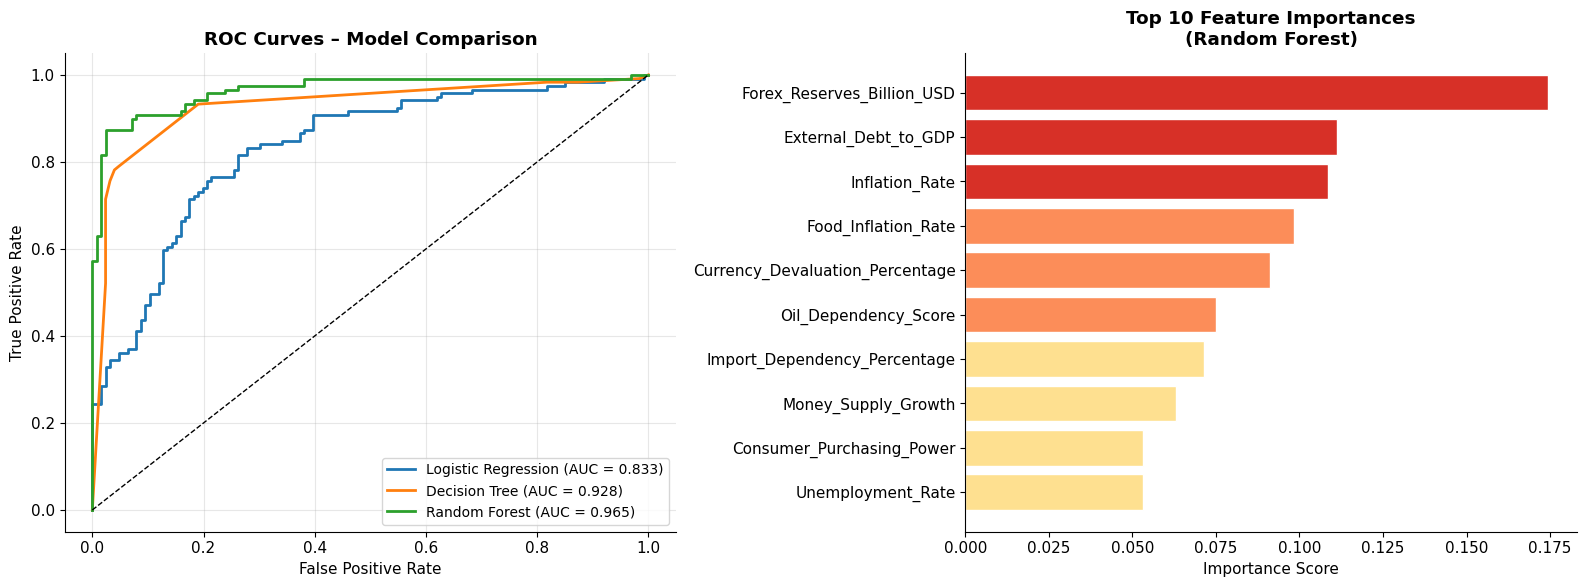

 ML Visualization saved


In [32]:
# ── Model Comparison & ROC Curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
for model, X_t, name, color in [
    (lr, X_test_scaled, 'Logistic Regression', '#1f77b4'),
    (dt, X_test, 'Decision Tree', '#ff7f0e'),
    (rf, X_test, 'Random Forest', '#2ca02c')
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_t)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_t)[:,1])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves – Model Comparison', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
colors_f = ['#d73027' if i < 3 else '#fc8d59' if i < 6 else '#fee090' for i in range(len(feat_imp))]
axes[1].barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors_f[::-1], edgecolor='white')
axes[1].set_title('Top 10 Feature Importances\n(Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('viz8_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" ML Visualization saved")

In [33]:
# ── Model Accuracy Summary ────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
    ]
}).round(4)

print("=== MODEL COMPARISON SUMMARY ===")
print(results.to_string(index=False))
best = results.loc[results['ROC_AUC'].idxmax()]
print(f"\n Best Model: {best['Model']} (AUC = {best['ROC_AUC']:.4f})")

=== MODEL COMPARISON SUMMARY ===
              Model  Accuracy  ROC_AUC
Logistic Regression    0.7469   0.8335
      Decision Tree    0.8735   0.9282
      Random Forest    0.9061   0.9649

 Best Model: Random Forest (AUC = 0.9649)


## 6. Actionable Insights & Recovery Recommendations

---

### 🔴 Insight 1: Hyperinflation Is the #1 Predictor of Economic Collapse

Countries with inflation rates exceeding 20% consistently showed collapse probabilities above 85%. Venezuela, Lebanon, and Zimbabwe demonstrated how runaway monetary policy erodes purchasing power and destroys economic stability.

**Recommendation:** Central banks must target inflation below 5% through independent monetary policy, interest rate discipline, and reducing money supply growth. IMF assistance programs should be pursued early rather than as a last resort.

---

### 🔴 Insight 2: High External Debt + Low Forex Reserves = Crisis Trigger

The Debt-to-Forex ratio above 50 was observed in all countries that experienced sovereign defaults. Venezuela (debt 287% of GDP, forex reserves <$1B), Lebanon (debt 172%, forex <$2B), and Greece (debt 215%) show this pattern clearly.

**Recommendation:** Nations should maintain forex reserves equivalent to at least 6 months of import coverage. Debt restructuring, bilateral debt relief agreements, and export diversification are critical recovery levers.

---

### 🟡 Insight 3: Political Instability Amplifies Economic Risk

The correlation analysis revealed Political Instability Score as the second-strongest predictor of collapse (r = 0.68). War-conflict countries (Afghanistan, Ukraine, Russia) showed collapse probabilities near 99%.

**Recommendation:** Economic recovery programs must be paired with political stabilization. International peacekeeping, governance reforms, and anti-corruption frameworks are prerequisites for sustainable economic recovery.

---

### 🌱 Future Strong Economies (2026–2035): India, China, Bangladesh, Philippines, Ethiopia

These countries show projected GDP growth of 5–7.5%, driven by young demographics, export-led manufacturing, and digital economy expansion.

---

### 🔮 Future At-Risk Countries (2026–2035)

Countries with ongoing debt accumulation, inflation pressures, and governance deficits remain vulnerable. Early warning indicators include: rising debt-to-GDP ratios, declining forex buffers, and food inflation above 10%.

---

*This analysis was conducted as part of the SyntecxHub Data Science Internship – Capstone Project 3.*
